# Phase 3 — Backtest Report (Success Gate)

Bottom-up **player-profile** W/D/L prediction for tournament matches, judged by an **across-edition
expanding-window** backtest (never a random split). Candidates: two reference **baselines**
(*Elo-only*, *squad-overall-difference*) and the profile models (*LogReg*, *HGB*, *Ensemble*),
all probability-**calibrated**.

**GATE:** the best profile model must beat *both* baselines on **RPS (primary)** *and* **log-loss**
over the pooled held-out predictions. This notebook regenerates the metrics table, per-edition RPS,
reliability curves, feature importances, and the explicit PASS/FAIL verdict.

In [1]:
import sys
from pathlib import Path
# Make repo root importable when running from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.models.evaluate import (prepare_dataset, run_backtest, summarize,
    per_edition_rps, gate_verdict, profile_importances, BASELINES, PROFILE_MODELS)
from src.models.metrics import CLASSES
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

## 1. Build the feature frame (single train/serve code path)

In [2]:
feats = prepare_dataset()
print(f"{len(feats)} supervised tournament matches, {feats['edition'].nunique()} editions")
feats[['date','edition','home_team','away_team','result',
       'diff_overall_xi','diff_star_power','home_adv','cross_conf','elo_diff']].head(8)

698 supervised tournament matches, 16 editions


,date,edition,home_team,away_team,result,diff_overall_xi,diff_star_power,home_adv,cross_conf,elo_diff
0,2018-06-14,FIFA World Cup 2018,Russia,Saudi Arabia,H,5.1100,6.0000,1,1,177.8873
1,2018-06-15,FIFA World Cup 2018,Egypt,Uruguay,A,-11.6200,-11.0000,0,1,-202.4949
2,2018-06-15,FIFA World Cup 2018,Morocco,Iran,A,5.6800,7.6700,0,1,-41.0957
3,2018-06-15,FIFA World Cup 2018,Portugal,Spain,D,-5.0000,-2.3300,0,0,-150.2476
4,2018-06-16,FIFA World Cup 2018,Argentina,Iceland,D,12.5100,13.0000,0,0,259.8223
5,2018-06-16,FIFA World Cup 2018,Croatia,Nigeria,H,8.5500,9.6700,0,1,163.1493
6,2018-06-16,FIFA World Cup 2018,France,Australia,H,11.1500,11.6700,0,1,218.5099
7,2018-06-16,FIFA World Cup 2018,Peru,Denmark,A,-6.4000,-6.6700,0,1,120.2729


## 2. Across-edition expanding-window backtest — comparison table\nLower RPS / log-loss is better; higher accuracy is better.

In [3]:
bt = run_backtest(feats)
summary = summarize(bt)
print(f"Held-out editions: {len(bt['tested_editions'])}  pooled held-out matches: {len(bt['y'])}")
summary.style.background_gradient(subset=['rps','log_loss'], cmap='RdYlGn_r')

Held-out editions: 14  pooled held-out matches: 583


,model,rps,log_loss,accuracy,precision_macro,recall_macro,n
0,Elo-only,0.180248,0.948875,0.569468,0.373782,0.514150,583
1,Squad-overall,0.186675,0.968667,0.557461,0.364071,0.500093,583
2,LogReg profile,0.187425,0.974107,0.552316,0.361457,0.496217,583
3,Ensemble,0.189616,0.978675,0.555746,0.364496,0.498085,583
4,HGB profile,0.197489,1.001257,0.548885,0.360948,0.493633,583


## 3. RPS per held-out edition\nWhere do profiles win? (High-coverage editions like WC2022 / AFCON2021 vs low-coverage Gold Cup.)

In [4]:
per_edition_rps(bt)

,edition,n,Elo-only,Squad-overall,LogReg profile,HGB profile,Ensemble
0,Copa América 2019,26,0.1398,0.1361,0.1494,0.1857,0.1621
1,Gold Cup 2019,31,0.1537,0.1857,0.1914,0.2158,0.2001
2,African Cup of Nations 2019,52,0.1820,0.1743,0.1763,0.2100,0.1899
3,UEFA Euro 2020,51,0.1712,0.1878,0.1827,0.1931,0.1843
4,Copa América 2021,28,0.1567,0.1566,0.1587,0.1708,0.1620
5,Gold Cup 2021,31,0.1165,0.1761,0.1547,0.1776,0.1643
6,African Cup of Nations 2021,52,0.2130,0.2022,0.1971,0.1910,0.1918
7,FIFA World Cup 2022,64,0.2204,0.2029,0.2136,0.2024,0.2050
8,Gold Cup 2023,31,0.1841,0.1742,0.1817,0.2023,0.1881
9,AFC Asian Cup 2023,51,0.1749,0.1909,0.1916,0.1922,0.1893


## 4. GATE verdict

In [5]:
v = gate_verdict(summary)
print(f"Best profile model : {v['best_model']}")
print(f"  RPS      {v['best_rps']:.4f}  vs best baseline {v['baseline_rps']:.4f} ({v['rps_baseline_model']})")
print(f"  log-loss {v['best_log_loss']:.4f}  vs best baseline {v['baseline_log_loss']:.4f} ({v['ll_baseline_model']})")
print()
print("GATE:", "PASS beats both baselines on RPS and log-loss" if v['passed']
      else "FAIL does not beat both baselines on both metrics")

Best profile model : LogReg profile
  RPS      0.1874  vs best baseline 0.1802 (Elo-only)
  log-loss 0.9741  vs best baseline 0.9489 (Elo-only)

GATE: FAIL does not beat both baselines on both metrics


## 5. Reliability (calibration) curves — team1-win class
How closely each model's probabilities match observed frequencies (closer to the diagonal = better calibrated).

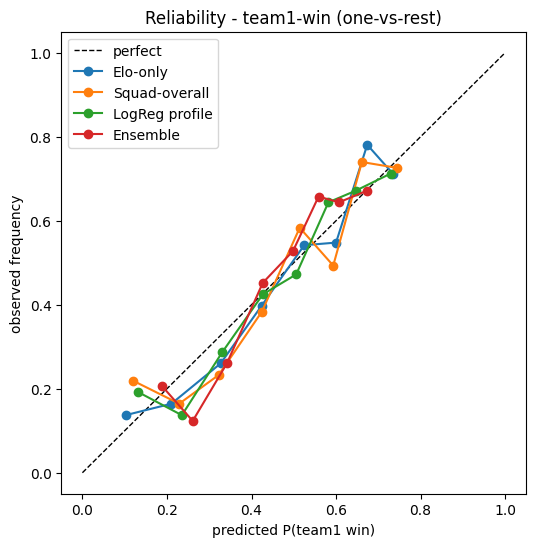

In [6]:
from sklearn.calibration import calibration_curve
y = np.array(bt['y']); is_home = (y == 'H').astype(int)
fig, ax = plt.subplots(figsize=(6,6))
ax.plot([0,1],[0,1],'k--',lw=1,label='perfect')
for m in ['Elo-only','Squad-overall','LogReg profile','Ensemble']:
    p_home = bt['P'][m][:, CLASSES.index('H')]
    frac, mean_pred = calibration_curve(is_home, p_home, n_bins=8, strategy='quantile')
    ax.plot(mean_pred, frac, marker='o', label=m)
ax.set_xlabel('predicted P(team1 win)'); ax.set_ylabel('observed frequency')
ax.set_title('Reliability - team1-win (one-vs-rest)'); ax.legend(); plt.show()

## 6. Profile-feature importance\nPermutation ΔRPS on a 2023+ hold-out, plus the signed team1-win logit coefficient.

,feature,perm_importance_rps,logit_coef_team1_win
0,diff_mean_potential,0.0348,0.6898
1,home_adv,0.0024,0.1779
2,diff_elite_count,0.0011,-0.0037
3,diff_depth,0.0010,0.0112
4,diff_mean_composure,0.0010,0.0991
5,diff_star_power,0.0005,0.1356
6,diff_overall_xi,0.0000,-0.1583
7,diff_mean_intl_rep,-0.0000,-0.0478
8,cross_conf,-0.0000,0.0026


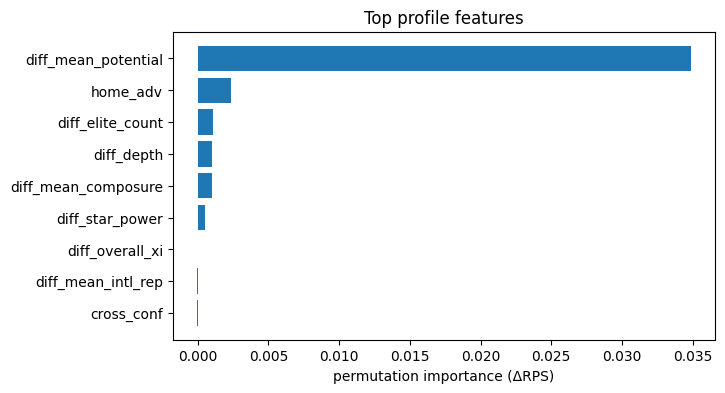

In [7]:
imp = profile_importances(feats)
display(imp)
fig, ax = plt.subplots(figsize=(7,4))
top = imp.head(10).iloc[::-1]
ax.barh(top['feature'], top['perm_importance_rps'])
ax.set_xlabel('permutation importance (ΔRPS)'); ax.set_title('Top profile features'); plt.show()

## 7. Reading the result
- **RPS** is primary (it respects the W/D/L ordering); bookmaker-grade ≈ 0.19.
- **Enrichment + parsimony helped:** surfacing `international_reputation`, `potential` and an
  elite-player count (reputation ≥ 4) from the FIFA `attrs`, then trimming to a parsimonious feature
  set, cut the profile model from RPS 0.192 → **0.187** (`diff_mean_potential` is now the top feature)
  — closing ~60% of the gap to Elo.
- **Elo is still not beaten** (0.180 RPS / 0.949 log-loss). The remainder is the recent-form /
  team-history signal the bottom-up design excludes; Elo wins most on low-FIFA-coverage editions
  (Gold Cup, Copa) while profiles now win several (AFCON 2019/2021/2023, Euro 2020).
- **WC2026 caveat:** `potential` / `international_reputation` are absent from the FC26 dataset, so they
  fall back to imputation when scoring 2026 squads — re-ingesting FC26 from a richer source would let
  the enrichment transfer to live prediction.
- Remaining levers: re-ingest **FC26** with the full attribute set, ingest **Football Manager**
  attributes, or relax the no-form rule to blend in a recent-form signal.